In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
import itertools as it
import pandas as pd
from datetime import datetime as dt
from datetime import timedelta
from pathlib import Path
from hypo_sleep import NumpyDecoder, Session
from scipy import signal, stats
import xarray as xr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from functools import partial
import re
import json
from functools import reduce
import pdb

In [2]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
# h1_dates = ["2024-05-21_10-28-00", "2024-05-23_06-00-36"]
# h2_dates = [
#     "2024-07-22_10-47-00",
#     "2024-07-23_05-47-21",
#     "2024-07-23_12-06-25",
#     "2024-07-25_05-55-34",
#     "2024-07-25_12-18-59",
# ]
# h3_dates = [
#     "2025-02-18_09-19-26",
#     "2025-02-20_08-58-57",
#     "2025-03-20_09-01-41",
# ]
# h4_dates = [
#     "2025-02-24_09-00-29",
# ]
full_dict = {
    "none": {
        "dates": [
            "2024-05-21_10-28-00",
            "2024-05-23_06-00-36",
            "2024-07-22_10-47-00",
            "2024-07-23_05-47-21",
            "2024-07-23_12-06-25",
            "2024-07-25_05-55-34",
            "2024-07-25_12-18-59",
            "2025-02-18_09-19-26",
            "2025-02-20_08-58-57",
            "2025-03-20_09-01-41",
            "2025-02-24_09-00-29",
            # "2025-02-26_09-05-08",
        ],
        "configs": [
            "55a4",
            "929a",
            "3ad9",
            "20a7",
            "f9f7",
            "1f25",
            "70eb",
            "5d77",
            "790d",
            "8a55",
            "3e4b",
            # "d205",
        ],
        "animal": [
            "HYDO01",
            "HYDO01",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO03",
            "HYDO03",
            "HYDO03",
            "HYDO04",
        ],  # "HYDO04"],
    },
    "sleep": {
        "dates": [
            "2025-02-19_08-59-23",
            "2025-03-03_08-55-10",
            "2025-02-25_09-06-23",
            "2025-03-07_08-52-44",
        ],
        "configs": [
            "d628",
            "c687",
            "073a",
            "9080",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04", "HYDO04"],
    },
    "food": {
        "dates": [
            "2025-02-21_09-04-29",
            "2025-02-28_09-02-06",
            "2025-03-04_08-55-25",
        ],
        "configs": [
            "a964",
            "0674",
            "bc96",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04"],
    },
}
depth_ordered_chs = {
    "HYDO01": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO02": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO03": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
    "HYDO04": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
}
triggers = ["spi-peak", "so-peak", "nrem-null"]

In [3]:
config_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
session_dict = {}
animal_dict = full_dict["none"]
for animal, date, config_id in zip(
    animal_dict["animal"], animal_dict["dates"], animal_dict["configs"]
):
    tmp_session_path = Path(config_path, animal, date, config_id, "state_dict.json")
    if not tmp_session_path.exists():
        print(f"Session path {tmp_session_path} does not exist, skipping")
        continue
    with open(tmp_session_path, "r") as f:
        state_dict = json.load(f, cls=NumpyDecoder)
    session_dict[date] = state_dict

In [4]:
date_animal_dict = {
    animal: [
        date
        for tmp_animal, date in zip(animal_dict["animal"], animal_dict["dates"])
        if tmp_animal == animal
    ]
    for animal in set(animal_dict["animal"])
}

In [64]:
## to load
SAVE = False
DELETE = False
PLOT = False
weighted = True
epoch = True
load_all = False
tmp_save_path = Path(
    "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/resamp_mua/"
)
tmp_trig = "spi-peak"
region = "ctx"
resamp_rate = "25ms"
mua_id = "398b"
weight = "_weighted" if weighted else ""
dim_to_concat = "epoch" if epoch else "trial"
epoch_corr_dict = {
    trig: {
        animal: {"acorr": [], "xcorr": [], "weights": []}
        for animal in set(animal_dict["animal"])
    }
    for trig in triggers
}
for tmp_animal in ["HYDO01", "HYDO02", "HYDO03", "HYDO04"]:
    print(tmp_animal)

    loaded_acorr_paths = []
    loaded_xcorr_paths = []
    corr_dict = epoch_corr_dict[tmp_trig][tmp_animal]
    # for trig, a_dict in epoch_corr_dict.items():
    #     if trig != "spi-peak":
    #         continue

    #     for animal, corr_dict in a_dict.items():
    #         if animal not in [
    #             "HYDO04",
    #         ]:
    #             continue
    acorr_path = Path(
        tmp_save_path,
        # f"{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-398b_{resamp_rate}{weight}_acorr.nc",
        f"{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-398b_acorr.nc",
    )
    xcorr_path = Path(
        tmp_save_path,
        # f"{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-398b_lfp-{region}_{resamp_rate}{weight}_xcorr.nc",
        f"{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-398b_lfp-{region}_xcorr.nc",
    )
    if acorr_path.exists() & load_all:
        corr_dict["acorr"] = xr.load_dataarray(
            Path(acorr_path),
            engine="h5netcdf",
        )
    else:
        tmp_acorr = []
        for date in date_animal_dict[tmp_animal]:
            acorr_date_path = Path(
                tmp_save_path,
                f"{tmp_trig}_{date}_{tmp_animal}_{dim_to_concat}_mua-{mua_id}_acorr_{resamp_rate}.nc",
            )
            if acorr_date_path.exists():
                tmp_acorr.append(
                    xr.load_dataarray(
                        Path(acorr_date_path),
                        engine="h5netcdf",
                    )
                )
                loaded_acorr_paths.append(acorr_date_path)
            else:
                print(f"acorr path {acorr_date_path} does not exist, skipping")
        tmp_acorr_xr = xr.concat(tmp_acorr, dim=dim_to_concat)
        corr_dict["acorr"] = tmp_acorr_xr.assign_coords(
            {dim_to_concat: np.arange(tmp_acorr_xr.sizes[dim_to_concat])}
        )
    if xcorr_path.exists() & load_all:
        corr_dict["xcorr"] = xr.load_dataarray(
            Path(xcorr_path),
            engine="h5netcdf",
        )
    else:
        tmp_xcorr = []
        for date in date_animal_dict[tmp_animal]:
            xcorr_date_path = Path(
                tmp_save_path,
                f"{tmp_trig}_{date}_{tmp_animal}_{dim_to_concat}_mua-{mua_id}_lfp-{region}_xcorr_{resamp_rate}.nc",
            )

            if xcorr_date_path.exists():
                tmp_xcorr.append(
                    xr.load_dataarray(
                        Path(xcorr_date_path),
                        engine="h5netcdf",
                    )
                )
                loaded_xcorr_paths.append(xcorr_date_path)
            else:
                print(f"xcorr path {xcorr_date_path} does not exist, skipping")

        # if not epoch:
        tmp_xcorr_xr = xr.concat(tmp_xcorr, dim=dim_to_concat)
        corr_dict["xcorr"] = tmp_xcorr_xr.assign_coords(
            {dim_to_concat: np.arange(tmp_xcorr_xr.sizes[dim_to_concat])}
        )
        # else:
        #     corr_dict["xcorr"] = tmp_xcorr
    if weighted:
        weights = []
        for date in date_animal_dict[tmp_animal]:
            date_weight_path = Path(
                tmp_save_path,
                f"{tmp_trig}_{date}_{tmp_animal}_{dim_to_concat}_mua-{mua_id}_weights_{resamp_rate}.nc",
            )
            if date_weight_path.exists():
                weights.append(
                    xr.load_dataarray(
                        Path(date_weight_path),
                        engine="h5netcdf",
                    )
                )
            else:
                print(f"weight path {date_weight_path} does not exist, skipping")
        tmp_weights_xr = xr.concat(weights, dim=dim_to_concat)
        corr_dict["weights"] = tmp_weights_xr.assign_coords(
            {dim_to_concat: np.arange(tmp_weights_xr.sizes[dim_to_concat])}
        )
        corr_dict["xcorr_weighted"] = (
            corr_dict["xcorr"]
            .sel(shuffle=0)
            .weighted(corr_dict["weights"])
            .mean(dim=dim_to_concat)
        )
        corr_dict["acorr_weighted"] = (
            corr_dict["acorr"]
            .sel(shuffle=0)
            .weighted(corr_dict["weights"])
            .mean(dim=dim_to_concat)
        )

    if SAVE:
        corr_dict["xcorr"].to_netcdf(
            Path(
                tmp_save_path,
                f"{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-398b_lfp-{region}_{resamp_rate}{weight}_xcorr.nc",
            ),
            engine="h5netcdf",
        )
        corr_dict["acorr"].to_netcdf(
            Path(
                tmp_save_path,
                f"{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-398b_{resamp_rate}{weight}_acorr.nc",
            ),
            engine="h5netcdf",
        )
    if DELETE:
        for path in loaded_xcorr_paths:
            path.unlink()
        for path in loaded_acorr_paths:
            path.unlink()
    if PLOT:
        figure_path = Path(
            f"/gpfs01/born/animal/DanielG/hypo_sleep/figures/mua_corr/{resamp_rate}/{tmp_trig}/{tmp_animal}"
        )
        figure_path.mkdir(parents=True, exist_ok=True)
        Path(figure_path, "acorr", "x_chs").mkdir(parents=True, exist_ok=True)
        Path(figure_path, "xcorr", "x_chs").mkdir(parents=True, exist_ok=True)
        Path(figure_path, "acorr", "x_lags").mkdir(parents=True, exist_ok=True)
        Path(figure_path, "xcorr", "x_lags").mkdir(parents=True, exist_ok=True)
        for tmp_ch in depth_ordered_chs[tmp_animal]:
            for corr_key, corr_data in corr_dict.items():
                fig, axs = plt.subplots(
                    nrows=5,
                    ncols=8,
                    figsize=(25, 20),
                    sharex=True,
                    sharey=True,
                    constrained_layout=True,
                )
                pval_dict = {}
                bins = (
                    np.linspace(-0.2, 1.5, 200)
                    if corr_key == "acorr"
                    else np.linspace(-0.2, 0.2, 100)
                )
                for ax, tmp_lag in zip(axs.ravel(), range(-20, 20)):
                    if tmp_ch not in corr_data.channel.values:
                        ax.set_visible(False)
                        continue
                    orig_data = corr_data.sel(shuffle=0, channel=tmp_ch, lag=tmp_lag)
                    shuff_data = corr_data.sel(
                        shuffle=slice(1, 100), channel=tmp_ch, lag=tmp_lag
                    )

                    non_na_trials_orig = orig_data.dropna(dim="trial").trial.values
                    non_na_trials_shuff = shuff_data.dropna(dim="trial").trial.values
                    finite_trials1 = orig_data.trial.values[
                        xr.ufuncs.isfinite(orig_data)
                    ]
                    non_na_trials = reduce(
                        np.intersect1d,
                        [non_na_trials_orig, non_na_trials_shuff, finite_trials1],
                    )
                    _, pval, df = sm.stats.ttest_ind(
                        orig_data.sel(trial=non_na_trials).values.ravel(),
                        shuff_data.sel(trial=non_na_trials).values.ravel(),
                    )
                    pval_dict[tmp_lag] = pval
                    ax.hist(
                        orig_data.sel(trial=non_na_trials).values.ravel(),
                        bins=bins,
                        alpha=0.7,
                        label="real",
                        density=True,
                        color="#dbb219",
                    )
                    ax.hist(
                        shuff_data.sel(trial=non_na_trials).values.ravel(),
                        bins=bins,
                        alpha=0.7,
                        label="shuff",
                        density=True,
                        color="#ab345e",
                    )
                    if tmp_lag == -20:
                        ax.legend()
                    ax.set_title(f"lag {tmp_lag} - p={pval:.3e}")
                    ax.spines[["top", "right"]].set_visible(False)
                    # print(f"lag {tmp_lag} df: {df}")
                sub_title = (
                    f"{corr_key} w/{region}" if corr_key == "xcorr" else f"{corr_key}"
                )
                fig.suptitle(
                    f"{resamp_rate} -> 4ms MUA {sub_title}\n{tmp_animal} - {tmp_trig} - Ch {tmp_ch}",
                    fontsize=16,
                    y=1.04,
                )
                fig.supxlabel(f"{corr_key} coeff [-1, 1]")
                if corr_key == "acorr":
                    fig_save_path = Path(
                        figure_path,
                        "acorr",
                        "x_chs",
                        f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-{mua_id}_acorr_hist_ch{int(tmp_ch):02d}_wide{weight}.png",
                    )
                elif corr_key == "xcorr":
                    fig_save_path = Path(
                        figure_path,
                        "xcorr",
                        "x_chs",
                        f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-{mua_id}_xcorr-{region}_hist_ch{int(tmp_ch):02d}_wide{weight}.png",
                    )
                fig.savefig(
                    fig_save_path,
                    dpi=300,
                    facecolor="white",
                    transparent=False,
                    bbox_inches="tight",
                )
                plt.close()
        lags = np.concatenate(
            [np.arange(-21, -15), np.arange(-12, 12, 2), np.arange(15, 22)]
        )
        for tmp_lag in lags:
            if tmp_lag == 0:
                continue
            for corr_key, corr_data in corr_dict.items():
                fig, axs = plt.subplots(
                    nrows=8,
                    ncols=4,
                    figsize=(20, 20),
                    sharex=True,
                    sharey=True,
                    constrained_layout=True,
                )
                pval_dict = {}
                bins = (
                    np.linspace(-0.2, 1.5, 200)
                    if corr_key == "acorr"
                    else np.linspace(-0.2, 0.2, 100)
                )
                for ind, (ax, tmp_ch) in enumerate(
                    zip(axs.ravel(), depth_ordered_chs[tmp_animal][::-1])
                ):
                    if tmp_ch not in corr_data.channel.values:
                        continue
                    orig_data = corr_data.sel(shuffle=0, channel=tmp_ch, lag=tmp_lag)
                    shuff_data = corr_data.sel(
                        shuffle=slice(1, 100), channel=tmp_ch, lag=tmp_lag
                    )

                    non_na_trials_orig = orig_data.dropna(dim="trial").trial.values
                    non_na_trials_shuff = shuff_data.dropna(dim="trial").trial.values
                    finite_trials1 = orig_data.trial.values[
                        xr.ufuncs.isfinite(orig_data)
                    ]
                    non_na_trials = reduce(
                        np.intersect1d,
                        [non_na_trials_orig, non_na_trials_shuff, finite_trials1],
                    )
                    _, pval, df = sm.stats.ttest_ind(
                        orig_data.sel(trial=non_na_trials).values.ravel(),
                        shuff_data.sel(trial=non_na_trials).values.ravel(),
                    )
                    pval_dict[tmp_ch] = pval
                    ax.hist(
                        orig_data.sel(trial=non_na_trials).values.ravel(),
                        bins=bins,
                        alpha=0.7,
                        label="real",
                        density=True,
                        color="#dbb219",
                    )
                    ax.hist(
                        shuff_data.sel(trial=non_na_trials).values.ravel(),
                        bins=bins,
                        alpha=0.7,
                        label="shuff",
                        density=True,
                        color="#ab345e",
                    )
                    if ind == 0:
                        ax.legend()
                    ax.set_title(f"ch {tmp_ch}, p={pval:.3e}")
                    ax.spines[["top", "right"]].set_visible(False)
                    # print(f"lag {tmp_lag} df: {df}")
                sub_title = (
                    f"{corr_key} w/{region}" if corr_key == "xcorr" else f"{corr_key}"
                )
                fig.suptitle(
                    f"{resamp_rate} -> 4ms MUA {sub_title}\n{tmp_animal} - {tmp_trig} - Lag {tmp_lag} ~{int(np.round(1 / (tmp_lag * 0.004)))} Hz",
                    fontsize=16,
                    y=1.04,
                )
                fig.supxlabel(f"{corr_key} coeff [-1, 1]")
                sign_label = "pos" if tmp_lag > 0 else "neg"
                if corr_key == "acorr":
                    fig_save_path = Path(
                        figure_path,
                        "acorr",
                        "x_lags",
                        f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-{mua_id}_acorr_hist_lag{np.abs(tmp_lag):02d}-{sign_label}_wide{weight}.png",
                    )
                elif corr_key == "xcorr":
                    fig_save_path = Path(
                        figure_path,
                        "xcorr",
                        "x_lags",
                        f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-{mua_id}_xcorr-{region}_hist_lag{np.abs(tmp_lag):02d}-{sign_label}_wide{weight}.png",
                    )
                fig.savefig(
                    fig_save_path,
                    dpi=300,
                    facecolor="white",
                    transparent=False,
                    bbox_inches="tight",
                )
                plt.close()
        for corr_key, corr_data in corr_dict.items():
            fig, axs = plt.subplots(
                nrows=8,
                ncols=4,
                figsize=(20, 20),
                constrained_layout=True,
                sharex=True,
                sharey=True,
            )
            for tmp_ch, ax in zip(depth_ordered_chs[tmp_animal][::-1], axs.ravel()):
                if tmp_ch not in corr_data.channel.values:
                    continue
                tmp_data = corr_data.sel(shuffle=0, channel=tmp_ch, lag=slice(-50, 50))
                tmp_mean = tmp_data.mean(dim="trial", skipna=True)
                tmp_sem = tmp_data.std(dim="trial") / np.sqrt(tmp_data.sizes["trial"])
                ax.plot(tmp_mean.lag.values, tmp_mean)
                ax.fill_between(
                    tmp_mean.lag.values,
                    tmp_mean - tmp_sem,
                    tmp_mean + tmp_sem,
                    alpha=1,
                    color="orange",
                )
                ax.axvspan(-21, -15, color="purple", alpha=0.2)
                ax.axvspan(15, 21, color="purple", alpha=0.2)
                ax.set_title(f"ch {tmp_ch}")
                ax.spines[["top", "right"]].set_visible(False)
                if corr_key == "acorr":
                    ax.set_ylim([-0.05, 2.5])
                    ax.set_yscale("log")
                else:
                    ax.set_ylim([-0.015, 0.015])
            sub_title = (
                f"{corr_key} w/{region}" if corr_key == "xcorr" else f"{corr_key}"
            )
            fig.suptitle(
                f"{resamp_rate} -> 4ms bin MUA {sub_title}\n{tmp_animal} {tmp_trig}",
                fontsize=16,
                y=1.02,
            )
            fig.supxlabel("lag (4ms)")
            fig.supylabel("Z[corr coeff]")
            if corr_key == "acorr":
                fig_save_path = Path(
                    figure_path,
                    f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-{mua_id}_acorr-log{weight}.png",
                )
            elif corr_key == "xcorr":
                fig_save_path = Path(
                    figure_path,
                    f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_{dim_to_concat}_mua-{mua_id}_xcorr-{region}{weight}.png",
                )
            fig.savefig(
                fig_save_path,
                dpi=300,
                facecolor="white",
                transparent=False,
                bbox_inches="tight",
            )
            plt.close()

HYDO01
HYDO02
HYDO03
HYDO04


In [59]:
frames = []
for trig, animal_data in epoch_corr_dict.items():
    if trig != "spi-peak":
        continue
    for animal, corr_data in animal_data.items():
        if animal not in ["HYDO01", "HYDO02"]:
            continue
        for cond in ["acorr_weighted", "xcorr_weighted"]:
            tmp_xr = corr_data[cond]
            for lag in np.arange(-50, 51):
                df = (
                    xr.ufuncs.abs(tmp_xr.sel(lag=lag))
                    .to_dataframe(name="value")
                    .reset_index()
                )
                df.drop(columns=["shuffle"], inplace=True)
                df["condition"] = "real"
                df["trig"] = trig
                df["animal"] = animal
                df["corr_type"] = cond.split("_")[0]
                frames.append(df)
for trig, animal_data in epoch_corr_dict.items():
    if trig != "spi-peak":
        continue
    for animal, corr_data in animal_data.items():
        if animal not in ["HYDO01", "HYDO02"]:
            continue
        for cond in ["acorr", "xcorr"]:
            shuff_data = corr_data[cond].sel(shuffle=1)
            for lag in np.arange(-50, 51):
                df = (
                    xr.ufuncs.abs(shuff_data.sel(lag=lag))
                    .to_dataframe(name="value")
                    .reset_index()
                )
                df.drop(columns=["shuffle", "epoch"], inplace=True)
                df["condition"] = "null"
                df["trig"] = trig
                df["animal"] = animal
                df["corr_type"] = cond

                frames.append(df)
df_all = pd.concat(frames, ignore_index=True)
# freqs = np.unique(np.concatenate(coh_dict[key]["peak"]["frequency"]))

In [61]:
ch_mean_df = df_all.groupby(["trig", "lag", "animal", "condition", "corr_type"]).agg(
    {"value": np.nanmean}
)
ch_mean_df = ch_mean_df.reset_index()

In [ ]:
idx = pd.IndexSlice
stat_res = {
    corr_type: {trig: {} for trig in triggers} for corr_type in ["xcorr", "acorr"]
}
for corr_type in stat_res.keys():
    corr_df = ch_mean_df.loc[ch_mean_df.corr_type == corr_type, :]
    for trig in triggers:
        trig_df = corr_df.loc[corr_df.trig == trig, :]
        for tmp_lag in lags:
            tmp_df = trig_df.loc[(trig_df.lag == tmp_lag), :]
            model1 = sm.formula.mixedlm(
                "value ~ C(condition, Treatment(reference='null'))",
                data=tmp_df,
                groups=tmp_df.animal,
            ).fit(reml=False, **{"maxiter": 5000})
            model2 = sm.formula.mixedlm(
                "value ~ 1",
                data=tmp_df,
                groups=tmp_df.animal,
            ).fit(reml=False, **{"maxiter": 5000})
            chi_sq_1_2 = 2 * (model1.llf - model2.llf)
            df_1_2 = model1.df_modelwc - model2.df_modelwc
            p_value_1_2 = stats.chi2.sf(chi_sq_1_2, df_1_2)
            if p_value_1_2 < 0.05:
                model = model1
            else:
                model = model2
            stat_res[corr_type][trig][f"{tmp_lag}"] = {
                "model": model,
                "p_value": p_value_1_2,
            }

In [9]:
for corr_key, corr_data in corr_dict.items():
    fig, axs = plt.subplots(
        nrows=8,
        ncols=4,
        figsize=(20, 20),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    for tmp_ch, ax in zip(depth_ordered_chs[tmp_animal][::-1], axs.ravel()):
        if tmp_ch not in corr_data.channel.values:
            continue
        tmp_data = corr_data.sel(shuffle=0, channel=tmp_ch, lag=slice(-50, 50))
        tmp_mean = tmp_data.mean(dim="trial", skipna=True)
        tmp_sem = tmp_data.std(dim="trial") / np.sqrt(tmp_data.sizes["trial"])
        ax.plot(tmp_mean.lag.values, tmp_mean)
        ax.fill_between(
            tmp_mean.lag.values,
            tmp_mean - tmp_sem,
            tmp_mean + tmp_sem,
            alpha=1,
            color="orange",
        )
        ax.axvspan(-21, -15, color="purple", alpha=0.2)
        ax.axvspan(15, 21, color="purple", alpha=0.2)
        ax.set_title(f"ch {tmp_ch}")
        ax.spines[["top", "right"]].set_visible(False)
        if corr_key == "acorr":
            ax.set_ylim([-0.05, 2.5])
            ax.set_yscale("log")
        else:
            ax.set_ylim([-0.015, 0.015])
    sub_title = f"{corr_key} w/{region}" if corr_key == "xcorr" else f"{corr_key}"
    fig.suptitle(
        f"{resamp_rate} -> 4ms bin MUA {sub_title}\n{tmp_animal} {tmp_trig}",
        fontsize=16,
        y=1.02,
    )
    fig.supxlabel("lag (4ms)")
    fig.supylabel("Z[corr coeff]")
    if corr_key == "acorr":
        fig_save_path = Path(
            figure_path,
            f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_trial_mua-{mua_id}_acorr-log.png",
        )

    elif corr_key == "xcorr":
        fig_save_path = Path(
            figure_path,
            f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_trial_mua-{mua_id}_xcorr-{region}.png",
        )
    fig.savefig(
        fig_save_path,
        dpi=300,
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
    )
    plt.close()

/tmp/ipykernel_3923489/3610569602.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-0.05, 2.5])
/tmp/ipykernel_3923489/3610569602.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-0.05, 2.5])
/tmp/ipykernel_3923489/3610569602.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-0.05, 2.5])
/tmp/ipykernel_3923489/3610569602.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-0.05, 2.5])
/tmp/ipykernel_3923489/3610569602.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-0.05, 2.5])
/tmp/ipykernel_3923489/3610569602.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-0.05, 2.5])
/tmp/ipykernel_3923489/3610569602.py:29: UserWarning: Attempt to set non-positive 

## Plotting

In [105]:
figure_path = Path(
    f"/gpfs01/born/animal/DanielG/hypo_sleep/figures/mua_corr/{resamp_rate}/{tmp_trig}/{tmp_animal}"
)
figure_path.mkdir(parents=True, exist_ok=True)
Path(figure_path, "x_chs").mkdir(exist_ok=True)
Path(figure_path, "x_lags").mkdir(exist_ok=True)

### plot all lags per each channel

In [113]:
for tmp_ch in depth_ordered_chs[tmp_animal]:
    for corr_key, corr_data in corr_dict.items():
        fig, axs = plt.subplots(
            nrows=5,
            ncols=8,
            figsize=(25, 20),
            sharex=True,
            sharey=True,
            constrained_layout=True,
        )
        pval_dict = {}
        bins = np.linspace(-0.2, 0.75, 100)
        for ax, tmp_lag in zip(axs.ravel(), range(-20, 20)):
            if tmp_ch not in corr_data.channel.values:
                ax.set_visible(False)
                continue
            orig_data = corr_data.sel(shuffle=0, channel=tmp_ch, lag=tmp_lag)
            shuff_data = corr_data.sel(
                shuffle=slice(1, 100), channel=tmp_ch, lag=tmp_lag
            )

            non_na_trials_orig = orig_data.dropna(dim="trial").trial.values
            non_na_trials_shuff = shuff_data.dropna(dim="trial").trial.values
            finite_trials1 = orig_data.trial.values[xr.ufuncs.isfinite(orig_data)]
            non_na_trials = reduce(
                np.intersect1d,
                [non_na_trials_orig, non_na_trials_shuff, finite_trials1],
            )
            _, pval, df = sm.stats.ttest_ind(
                orig_data.sel(trial=non_na_trials).values.ravel(),
                shuff_data.sel(trial=non_na_trials).values.ravel(),
            )
            pval_dict[tmp_lag] = pval
            ax.hist(
                orig_data.sel(trial=non_na_trials).values.ravel(),
                bins=bins,
                alpha=0.7,
                label="real",
                density=True,
                color="#dbb219",
            )
            ax.hist(
                shuff_data.sel(trial=non_na_trials).values.ravel(),
                bins=bins,
                alpha=0.7,
                label="shuff",
                density=True,
                color="#ab345e",
            )
            if tmp_lag == -20:
                ax.legend()
            ax.set_title(f"lag {tmp_lag} - p={pval:.3e}")
            ax.spines[["top", "right"]].set_visible(False)
            # print(f"lag {tmp_lag} df: {df}")
        sub_title = f"{corr_key} w/{region}" if corr_key == "xcorr" else f"{corr_key}"
        fig.suptitle(
            f"{resamp_rate} -> 4ms MUA {sub_title}\n{tmp_animal} - {tmp_trig} - Ch {tmp_ch}",
            fontsize=16,
            y=1.04,
        )
        fig.supxlabel(f"{corr_key} coeff [-1, 1]")
        if corr_key == "acorr":
            fig_save_path = Path(
                figure_path,
                "x_chs",
                f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_trial_mua-{mua_id}_acorr_hist_ch{int(tmp_ch):02d}.png",
            )
        elif corr_key == "xcorr":
            fig_save_path = Path(
                figure_path,
                "x_chs",
                f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_trial_mua-{mua_id}_xcorr-{region}_hist_ch{int(tmp_ch):02d}.png",
            )
        fig.savefig(
            fig_save_path,
            dpi=300,
            facecolor="white",
            transparent=False,
            bbox_inches="tight",
        )
        plt.close()

### plot all channels per each lag

In [ ]:
lags = np.concatenate([np.arange(-21, -15), np.arange(-12, 12, 2), np.arange(15, 22)])
for tmp_lag in lags:
    if tmp_lag == 0:
        continue
    for corr_key, corr_data in corr_dict.items():
        fig, axs = plt.subplots(
            nrows=8,
            ncols=4,
            figsize=(20, 20),
            sharex=True,
            sharey=True,
            constrained_layout=True,
        )
        pval_dict = {}
        bins = np.linspace(-0.2, 0.75, 100)
        for ind, (ax, tmp_ch) in enumerate(
            zip(axs.ravel(), depth_ordered_chs[tmp_animal][::-1])
        ):
            if tmp_ch not in corr_data.channel.values:
                continue
            orig_data = corr_data.sel(shuffle=0, channel=tmp_ch, lag=tmp_lag)
            shuff_data = corr_data.sel(
                shuffle=slice(1, 100), channel=tmp_ch, lag=tmp_lag
            )

            non_na_trials_orig = orig_data.dropna(dim="trial").trial.values
            non_na_trials_shuff = shuff_data.dropna(dim="trial").trial.values
            finite_trials1 = orig_data.trial.values[xr.ufuncs.isfinite(orig_data)]
            non_na_trials = reduce(
                np.intersect1d,
                [non_na_trials_orig, non_na_trials_shuff, finite_trials1],
            )
            _, pval, df = sm.stats.ttest_ind(
                orig_data.sel(trial=non_na_trials).values.ravel(),
                shuff_data.sel(trial=non_na_trials).values.ravel(),
            )
            pval_dict[tmp_ch] = pval
            ax.hist(
                orig_data.sel(trial=non_na_trials).values.ravel(),
                bins=bins,
                alpha=0.7,
                label="real",
                density=True,
                color="#dbb219",
            )
            ax.hist(
                shuff_data.sel(trial=non_na_trials).values.ravel(),
                bins=bins,
                alpha=0.7,
                label="shuff",
                density=True,
                color="#ab345e",
            )
            if ind == 0:
                ax.legend()
            ax.set_title(f"ch {tmp_ch}, p={pval:.3e}")
            ax.spines[["top", "right"]].set_visible(False)
            # print(f"lag {tmp_lag} df: {df}")
        sub_title = f"{corr_key} w/{region}" if corr_key == "xcorr" else f"{corr_key}"
        fig.suptitle(
            f"{resamp_rate} -> 4ms MUA {sub_title}\n{tmp_animal} - {tmp_trig} - Lag {tmp_lag} ~{int(np.round(1 / (tmp_lag * 0.004)))} Hz",
            fontsize=16,
            y=1.04,
        )
        fig.supxlabel(f"{corr_key} coeff [-1, 1]")
        sign_label = "pos" if tmp_lag > 0 else "neg"
        if corr_key == "acorr":
            fig_save_path = Path(
                figure_path,
                "x_lags",
                f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_trial_mua-{mua_id}_acorr_hist_lag{np.abs(tmp_lag):02d}-{sign_label}.png",
            )
        elif corr_key == "xcorr":
            fig_save_path = Path(
                figure_path,
                "x_lags",
                f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_trial_mua-{mua_id}_xcorr-{region}_hist_lag{np.abs(tmp_lag):02d}-{sign_label}.png",
            )
        fig.savefig(
            fig_save_path,
            dpi=300,
            facecolor="white",
            transparent=False,
            bbox_inches="tight",
        )
        plt.close()

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fc2e59a1430>>
Traceback (most recent call last):
  File "/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


### plot lags across channels

In [109]:
for corr_key, corr_data in corr_dict.items():
    fig, axs = plt.subplots(
        nrows=8,
        ncols=4,
        figsize=(20, 20),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    for tmp_ch, ax in zip(depth_ordered_chs[tmp_animal][::-1], axs.ravel()):
        if tmp_ch not in corr_data.channel.values:
            continue
        tmp_data = corr_data.sel(shuffle=0, channel=tmp_ch, lag=slice(-50, 50))
        tmp_mean = tmp_data.mean(dim="trial", skipna=True)
        tmp_sem = tmp_data.std(dim="trial") / np.sqrt(tmp_data.sizes["trial"])
        ax.plot(tmp_mean.lag.values, tmp_mean)
        ax.fill_between(
            tmp_mean.lag.values,
            tmp_mean - tmp_sem,
            tmp_mean + tmp_sem,
            alpha=1,
            color="orange",
        )
        ax.axvspan(-21, -15, color="purple", alpha=0.2)
        ax.axvspan(15, 21, color="purple", alpha=0.2)
        ax.set_title(f"ch {tmp_ch}")
        ax.spines[["top", "right"]].set_visible(False)
        if corr_key == "acorr":
            ax.set_ylim([-0.05, 3])
        else:
            ax.set_ylim([-0.025, 0.025])
    sub_title = f"{corr_key} w/{region}" if corr_key == "xcorr" else f"{corr_key}"
    fig.suptitle(
        f"{resamp_rate} -> 4ms bin MUA {sub_title}\n{tmp_animal} {tmp_trig}",
        fontsize=16,
        y=1.02,
    )
    fig.supxlabel("lag (4ms)")
    fig.supylabel("Z[corr coeff]")
    if corr_key == "acorr":
        fig_save_path = Path(
            figure_path,
            f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_trial_mua-{mua_id}_acorr.png",
        )
    elif corr_key == "xcorr":
        fig_save_path = Path(
            figure_path,
            f"{resamp_rate}_{tmp_trig}_{tmp_animal}_all_trial_mua-{mua_id}_xcorr-{region}.png",
        )
    fig.savefig(
        fig_save_path,
        dpi=300,
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
    )
    plt.close()

In [133]:
stats.ttest_1samp(spi_slice_corr_vals, 0, nan_policy="omit")

TtestResult(statistic=np.float64(-2.3520480554688787), pvalue=np.float64(0.018701945943610278), df=np.int64(6106))

/tmp/ipykernel_1226786/1827712598.py:13: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 100, using nperseg = 100
  f, Pxx = signal.welch(tmp_data, fs=250)


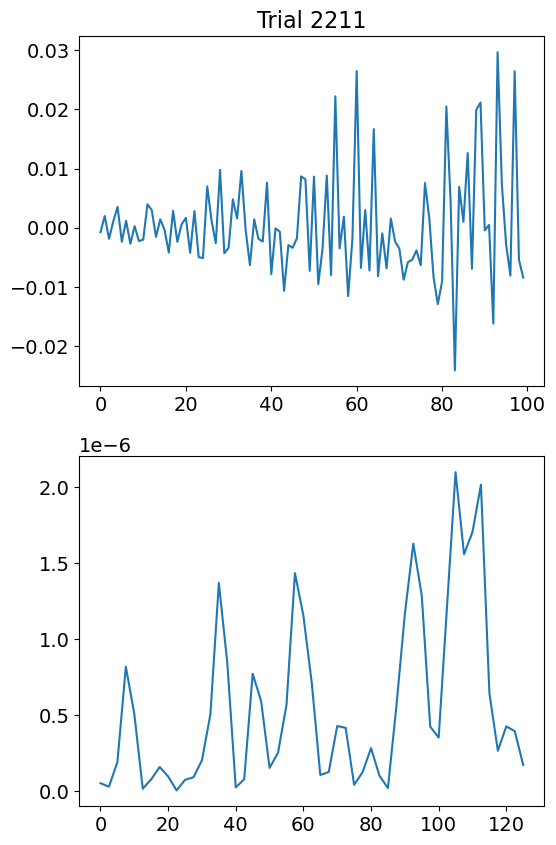

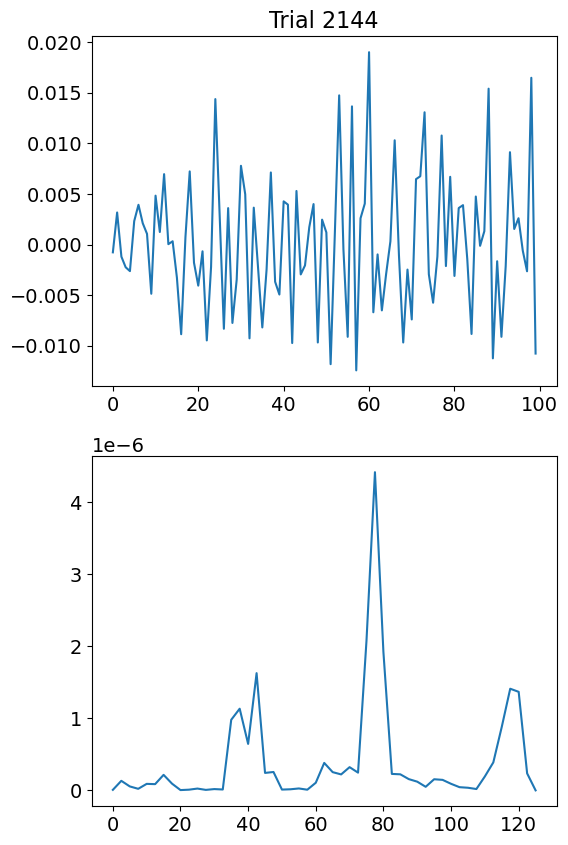

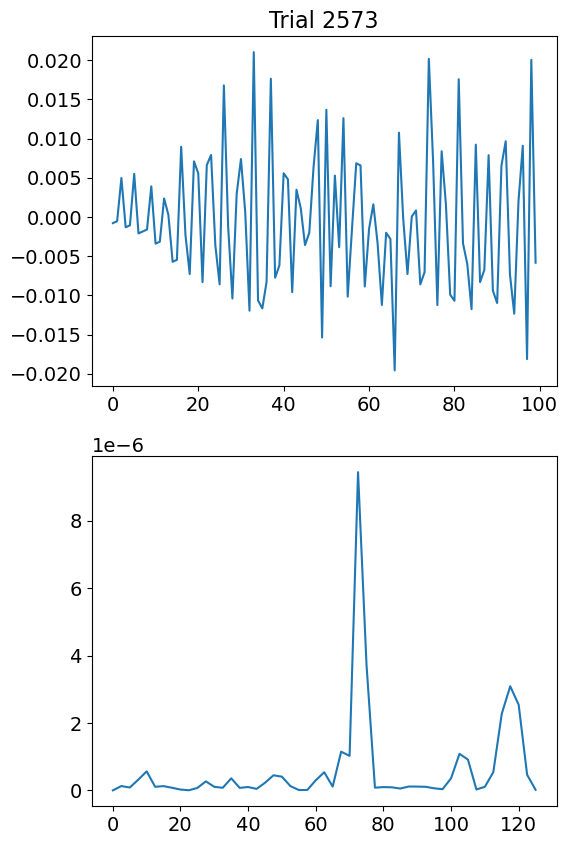

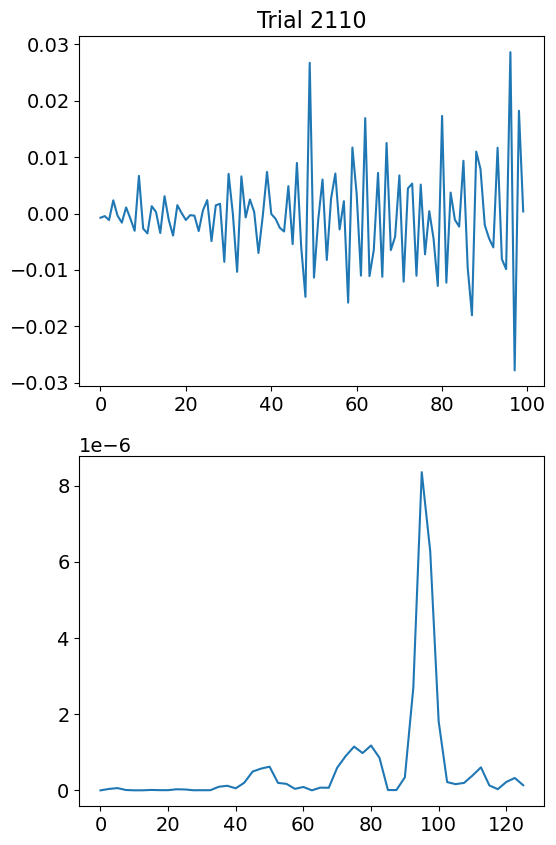

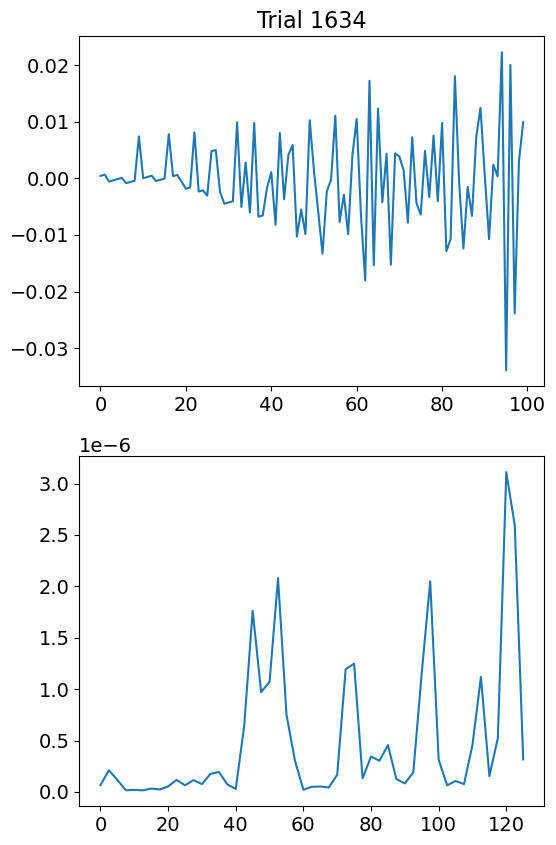

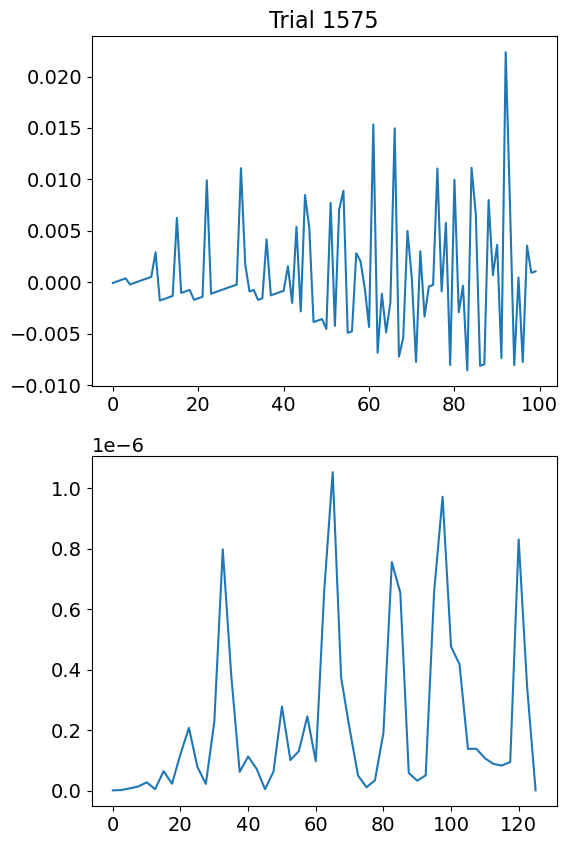

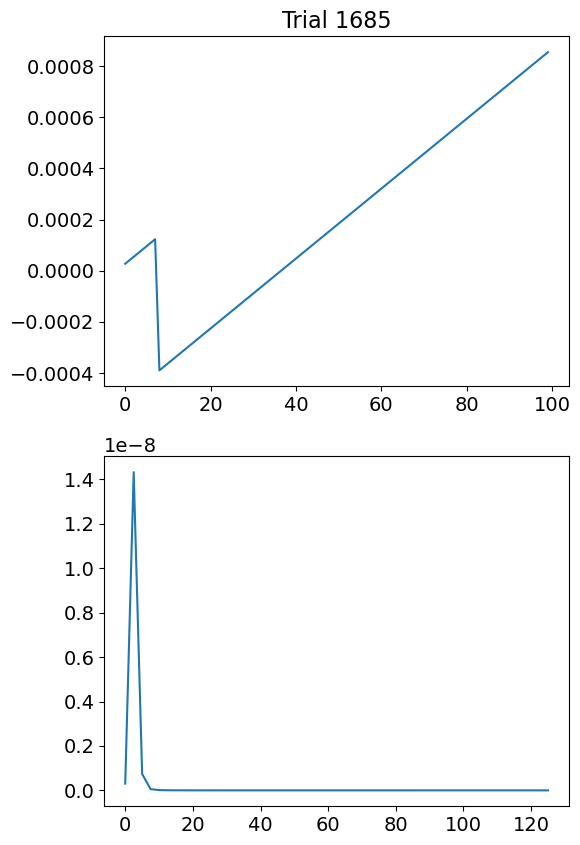

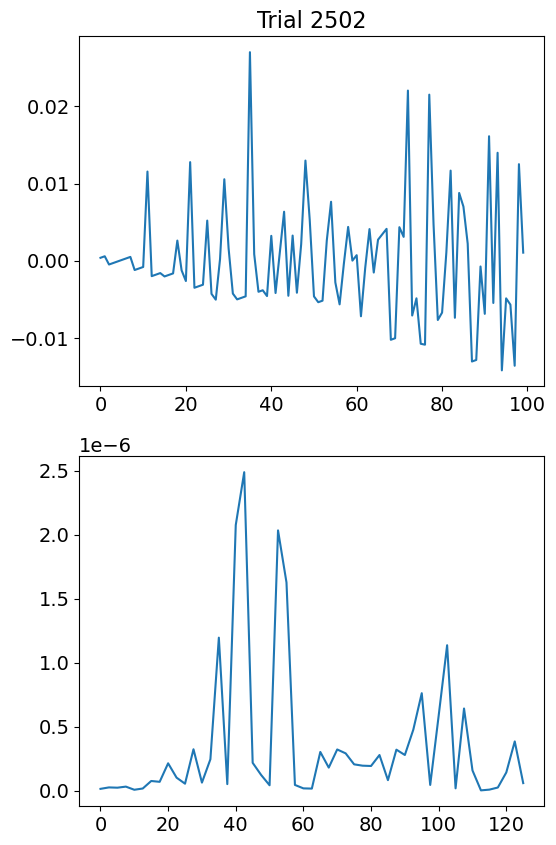

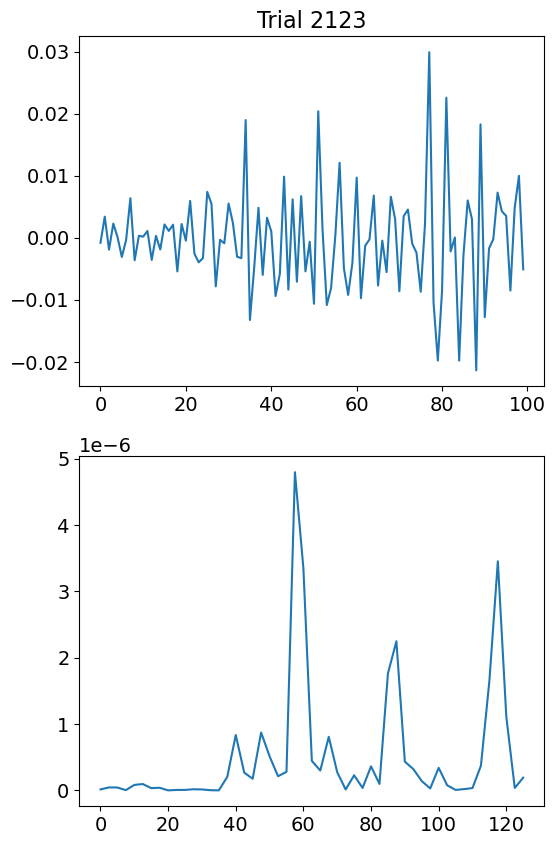

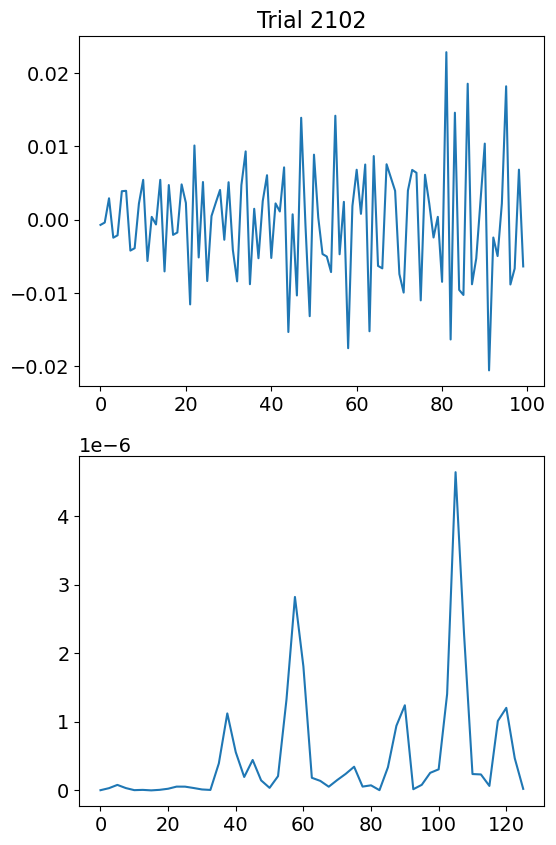

In [8]:
# day2
SEM = False
rng = np.random.default_rng()
re_a = tmp_a.assign_coords({"trial": np.arange(tmp_a.trial.values.size)})
date_edges = np.where(re_a.start_time.values[1:] - re_a.start_time.values[:-1] < 0)[0]
sub_a = re_a.isel(trial=slice(date_edges[0] + 1, date_edges[1] + 1))
rand_trials = rng.choice(sub_a.trial.values, size=10, replace=False)
for trial in rand_trials:
    tmp_data = sub_a.sel(channel="29").isel(lag=slice(0, 100)).sel(trial=trial)
    fig, axs = plt.subplots(nrows=2, figsize=(6, 10))
    axs[0].plot(tmp_data.lag.values, tmp_data)  # .mean(dim="trial"))
    axs[0].set_title(f"Trial {trial}")
    f, Pxx = signal.welch(tmp_data, fs=250)
    axs[1].plot(f, Pxx)
    if SEM:
        tmp_sem = tmp_data.std(dim="trial") / np.sqrt(tmp_data.sizes["trial"])
        axs[0].fill_between(
            tmp_data.lag.values,
            tmp_data.mean(dim="trial") - tmp_sem,
            tmp_data.mean(dim="trial") + tmp_sem,
            alpha=0.6,
            color="r",
        )

In [ ]:
tmp_session = Session(
    config_path, "HYDO02", "2025-02-18_09-19-26", "5d77", **{"base_path": "remote"}
)

In [8]:
from hypo_sleep.pipelines.mua_event import get_mua_stats, remove_bad_channels

In [89]:
params = {}
params["artifact_detect_std_thresh"] = 5
params["artifact_detect_method"] = "zscore"
params["artifact_detect_ch_frac"] = 0.2
params["artifact_removal_ms"] = 0.5
params["filter_Fs"] = 32_000
params["filter_edges"] = [300, 6000]
params["filter_method"] = "spikeinterface"
params["mua_std_thresh"] = 4.5
params["reference_id"] = "hyp_global_spk_9108"
params["reference_method"] = "global"
params["region"] = "hyp"
params["mua_id"] = "mua_4-5thresh_4s_baa2"

In [90]:
rec = tmp_session.hyp_rec
rectified_rec = remove_bad_channels(tmp_session, recording=rec, **params)

In [91]:
mua_dict = get_mua_stats(tmp_session, rec=rectified_rec, **params)

In [96]:
rng = np.random.default_rng()
re_a = tmp_a.assign_coords({"trial": np.arange(tmp_a.trial.values.size)})
date_edges = np.where(re_a.start_time.values[1:] - re_a.start_time.values[:-1] < 0)[0]
sub_a = re_a.isel(trial=slice(0, date_edges[0] + 1))

Text(0.5, 0.98, 'HYDO03')

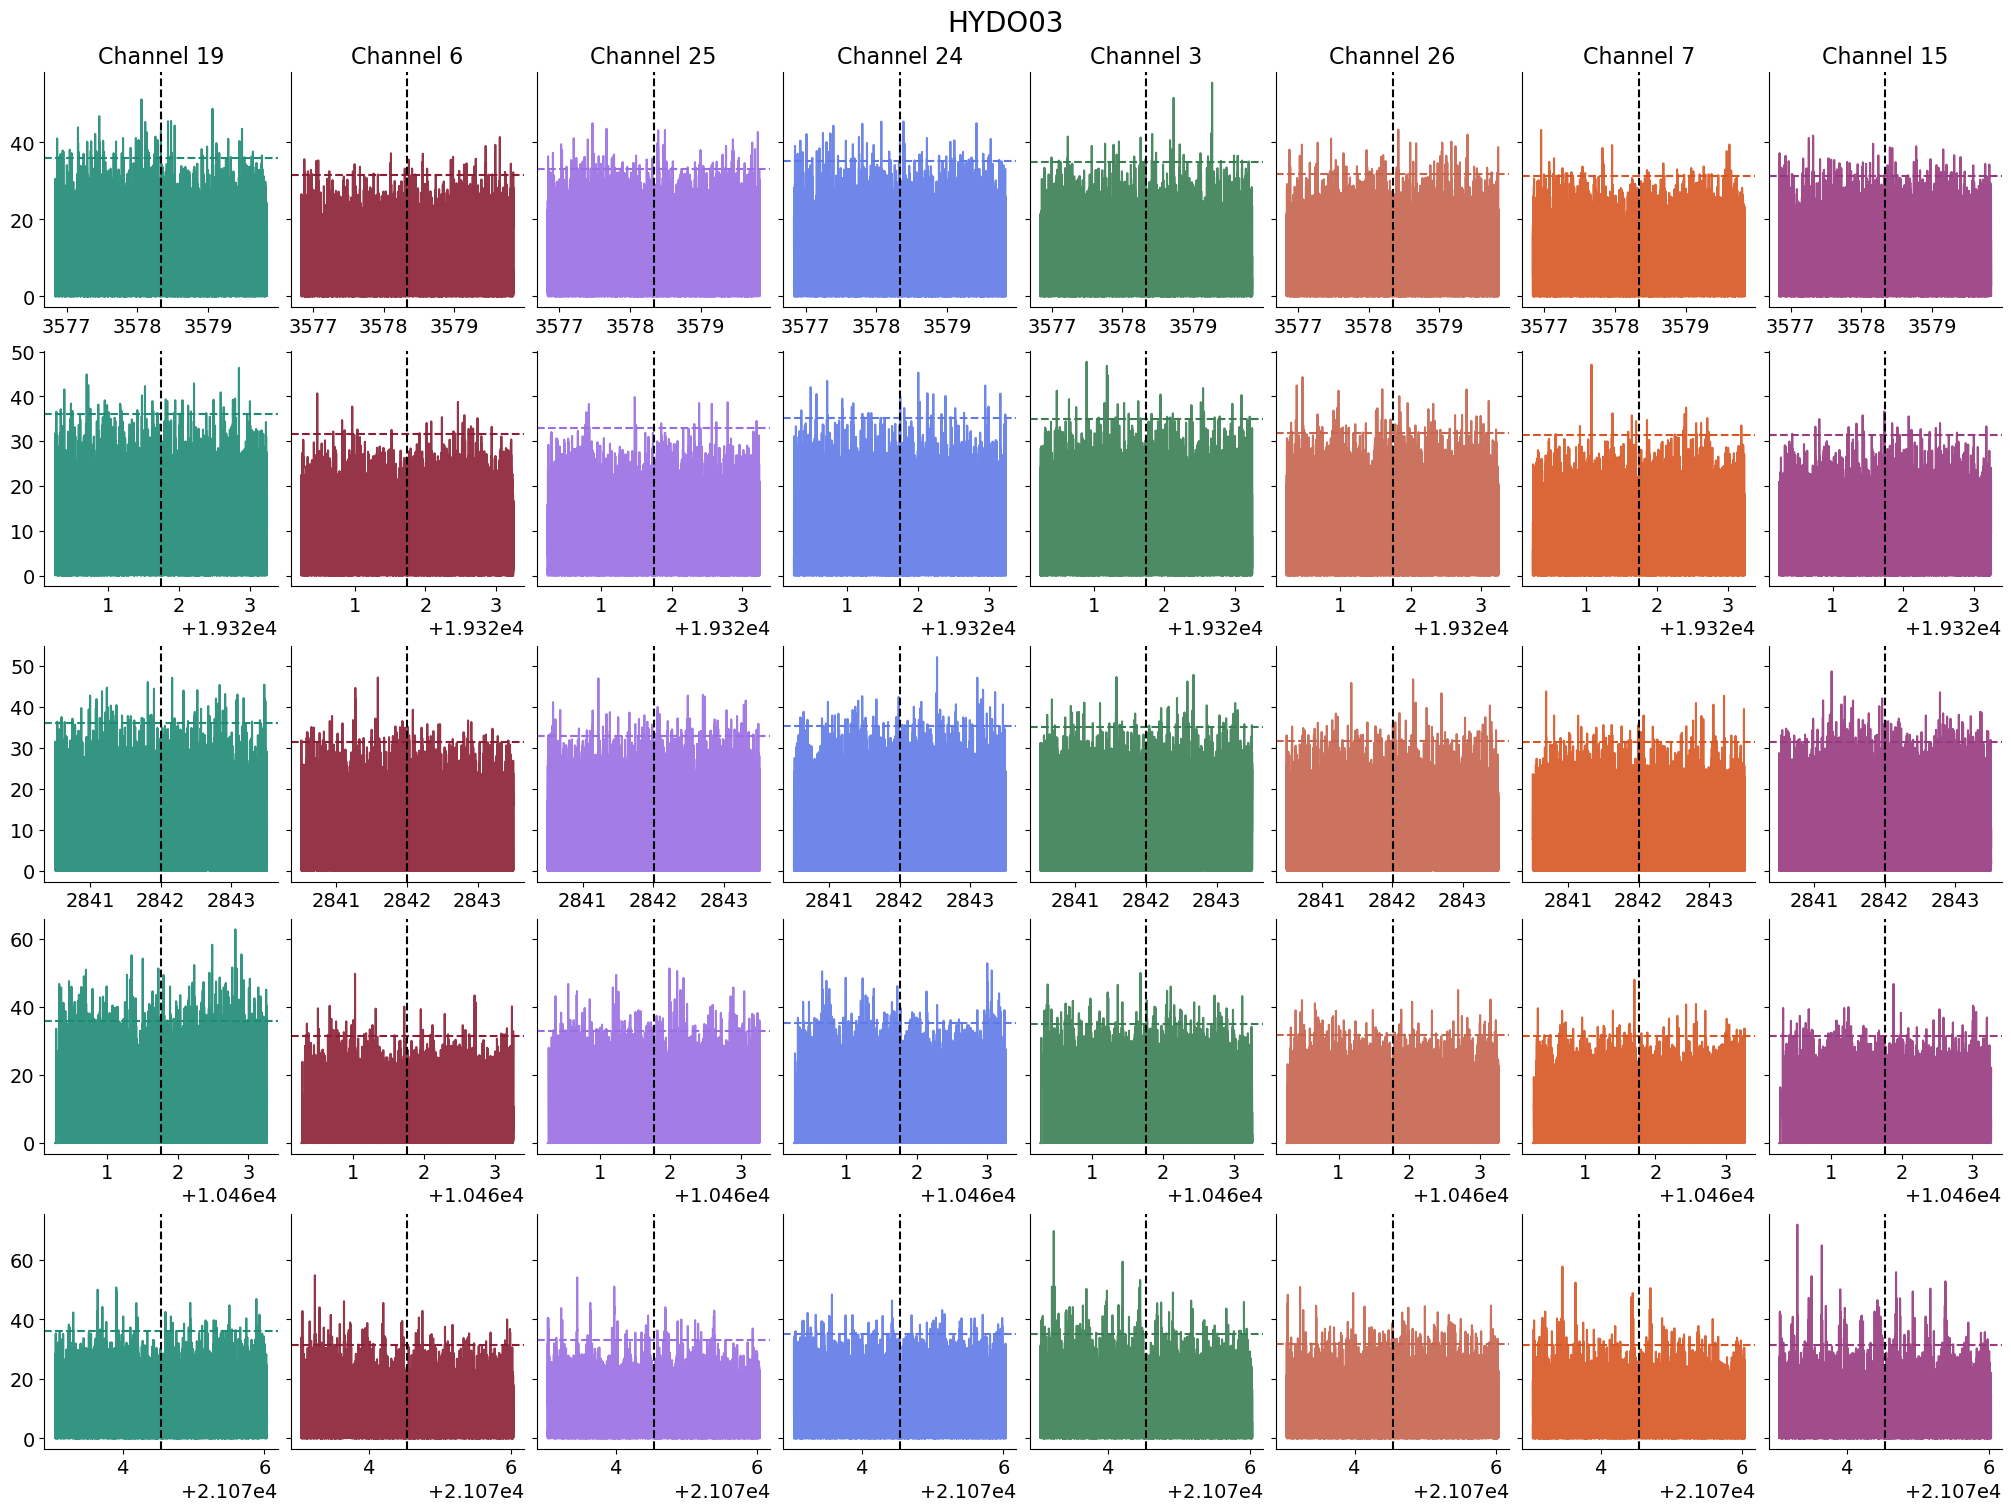

In [ ]:
# start_time = 3646.976
fig, axs = plt.subplots(
    nrows=5, ncols=8, sharey="row", figsize=(20, 15), constrained_layout=True
)
# rand_trials = rng.choice(sub_a.trial.values, size=5, replace=False)
for t_ind, tmp_trial in enumerate(rand_trials):
    start_time = sub_a.sel(trial=tmp_trial).start_time.values
    for ax, tmp_ch, tmp_c in zip(
        axs[t_ind, :].ravel(),
        # ["29", "24", "30", "18", "28", "20", "2", "13"],
        ["19", "6", "25", "24", "3", "26", "7", "15"],
        [
            "#1e8b75",
            "#8b1e34",
            "#996ee3",
            "#5f7ae7",
            "#397e53",
            "#c7644e",
            "#d85521",
            "#983a7f",
        ],
    ):
        tmp_rec = rectified_rec.select_channels(channel_ids=[tmp_ch]).time_slice(
            start_time=start_time - 1.5, end_time=start_time + 1.5
        )
        tmp_times = tmp_rec.get_times()
        tmp_trace = tmp_rec.get_traces(return_in_uV=True)

        ax.plot(tmp_times, tmp_trace, c=tmp_c, alpha=0.9)
        if t_ind == 0:
            ax.set_title(f"Channel {tmp_ch}")
        ax.axhline(
            y=mua_dict[tmp_ch]["mean"] + 3 * mua_dict[tmp_ch]["std"],
            color=tmp_c,
            linestyle="--",
        )
        ax.axvline(x=start_time, color="k", linestyle="--")
        ax.spines[["right", "top"]].set_visible(False)
fig.suptitle("HYDO03")